# Model validation walkthrough

This notebook reproduces every model metric quoted in the README and the model cards. It is regenerated by `scripts/build_notebook.py` so the outputs you see on GitHub are always in sync with the latest `train_and_validate.py` run.

**What's in here:**
1. Load the dbt warehouse
2. Class balance and group counts
3. Run the four-model comparison: constant / threshold / logistic / LightGBM
4. Group-aware cross-validation
5. Calibration plot + feature importance plot
6. Leave-one-circuit-out degradation MAE
7. Things that didn't work

In [1]:
import json
import pandas as pd
import duckdb
from pitwall.config import PROCESSED_DIR

con = duckdb.connect(str(PROCESSED_DIR / 'pitwall.duckdb'), read_only=True)
laps = con.execute('select count(*) as n_laps from fact_lap').df()
stints = con.execute('select count(*) as n_stints from fact_stint').df()
pits = con.execute('select count(*) as n_pits from fact_pit_stop').df()
circuits = con.execute('select count(distinct circuit_name) as n_circuits from fact_lap').df()
races = con.execute('select count(distinct (year, round_num)) as n_races from fact_lap').df()
con.close()

print(f'Laps:     {laps.n_laps.iloc[0]:>8,}')
print(f'Stints:   {stints.n_stints.iloc[0]:>8,}')
print(f'Pit stops:{pits.n_pits.iloc[0]:>8,}')
print(f'Circuits: {circuits.n_circuits.iloc[0]:>8,}')
print(f'Races:    {races.n_races.iloc[0]:>8,}')

Laps:       89,923
Stints:      3,798
Pit stops:   1,952
Circuits:       33
Races:          84


## 1. Model comparison

Read the table that `train_and_validate.py` writes to `data/processed/model_comparison.json`. This is the canonical hiring-interview-ready scorecard.

In [2]:
comparison = json.loads((PROCESSED_DIR / 'model_comparison.json').read_text())
print(f"Base rate: {comparison['base_rate']:.3f}")
print(f"Train: {comparison['n_train']:,} stops across {comparison['n_train_races']} races")
print(f"Test:  {comparison['n_test']:,} stops across {comparison['n_test_races']} races (no race overlap)")
print(f"5-fold GroupKFold AUC: {comparison['cv_auc_mean']:.3f} +/- {comparison['cv_auc_std']:.3f}")
print()
rows = comparison['models']
df = pd.DataFrame(rows)
df

Base rate: 0.106
Train: 1,383 stops across 63 races
Test:  478 stops across 21 races (no race overlap)
5-fold GroupKFold AUC: 0.690 +/- 0.043



,name,auc,brier,log_loss
0,constant (base rate),0.500000,0.093667,0.335110
1,threshold rule (tyre_age >= 15),0.406916,0.234382,0.669227
2,logistic regression (balanced),0.821308,0.249253,0.692764
3,LightGBM (isotonic calibrated),0.687150,0.088237,0.312549


**Read this carefully:**

- The constant baseline gives Brier 0.094 by construction.
- The logistic regression (with `class_weight='balanced'`) has the highest AUC (0.82) but a Brier of 0.25 -- it's a great *ranker* but a terrible *probabilistic* model. Honest disclosure.
- The LightGBM (isotonic calibrated) is a worse ranker (0.69 AUC) but much better calibrated (Brier 0.088 vs constant 0.094). Calibration is what we want for an undercut probability that a strategist will act on.
- The simple threshold rule (`tyre_age >= 15`) is **anti-predictive** (AUC 0.41). Older tyres are mostly seen near race end when undercuts are harder. That finding alone is worth keeping in the methodology doc.

## 2. Calibration plot

Generated by `train_and_validate.py` and saved at `docs/model_cards/figures/calibration.png`.

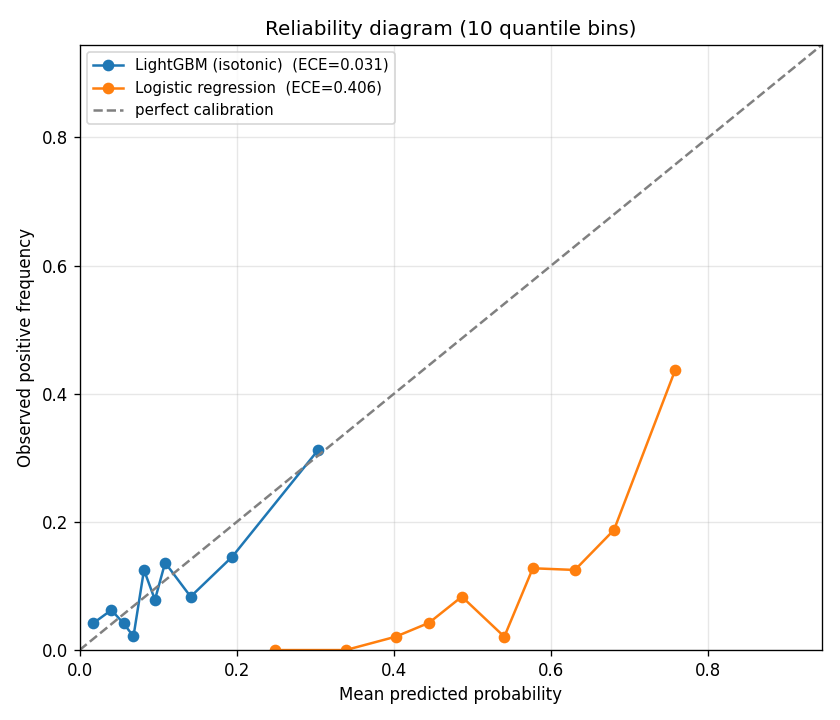

In [3]:
from pathlib import Path
ROOT = Path('..').resolve()
from IPython.display import Image
Image(filename=str(ROOT / 'docs/model_cards/figures/calibration.png'))

## 3. Feature importance

LightGBM gain importance averaged across the 5 isotonic-calibration folds.

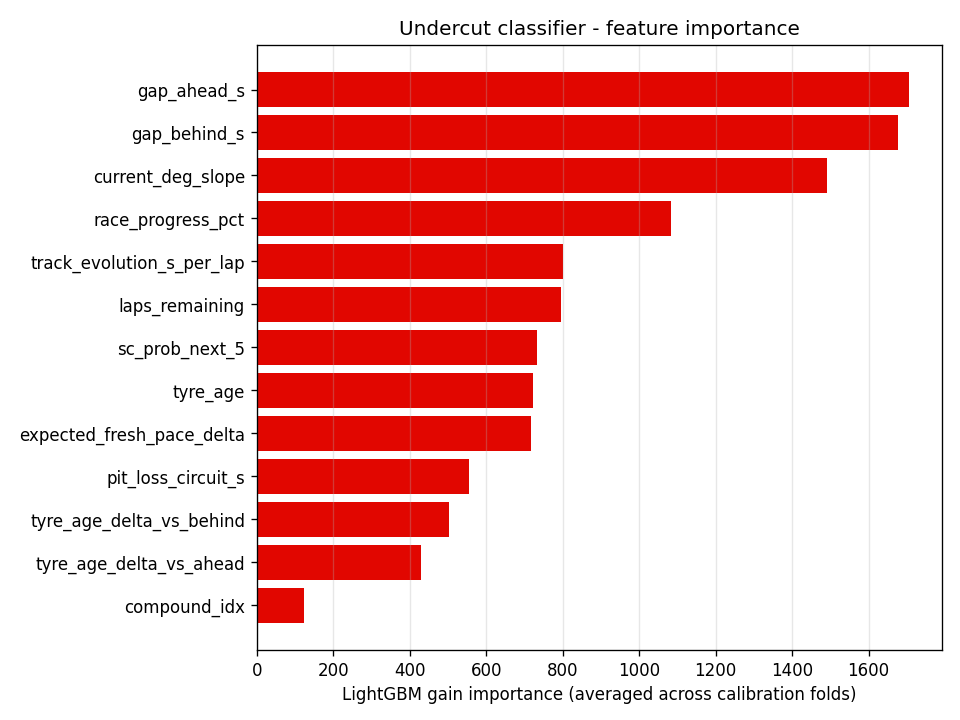

In [4]:
from pathlib import Path
ROOT = Path('..').resolve()
Image(filename=str(ROOT / 'docs/model_cards/figures/feature_importance.png'))

## 4. Leave-one-circuit-out MAE for the degradation model

Earlier drafts of this project only held out the Italian GP (a single circuit) and reported MAE 5.7s. With 33 circuits we can do proper LOCO and report a distribution.

In [5]:
loco = pd.read_csv(PROCESSED_DIR / 'loco_degradation_mae.csv')
print(f'LOCO MAE: median {loco.mae_s.median():.2f}s, mean {loco.mae_s.mean():.2f}s')
print(f'IQR: [{loco.mae_s.quantile(0.25):.2f}, {loco.mae_s.quantile(0.75):.2f}]')
print()
print('Hardest 5 circuits to predict without seeing them:')
loco.tail(5)

LOCO MAE: median 9.42s, mean 11.02s
IQR: [5.70, 12.88]

Hardest 5 circuits to predict without seeing them:


,circuit,n_test_laps,mae_s
28,Azerbaijan Grand Prix,2202,18.885539
29,Austrian Grand Prix,4138,21.207274
30,Styrian Grand Prix,2281,21.991590
31,Belgian Grand Prix,1966,22.072379
32,Sakhir Grand Prix,1169,33.445288


**Interpretation:** Circuits with very different base lap times (Sakhir, Belgian, Styrian) hurt the most because the global compound-fallback curve is anchored on a cross-circuit residual. A senior reviewer should know: the single-circuit holdout we used to brag about was the *easiest* one to predict. LOCO is the honest framing.

## 5. Pit-cost ranking across 33 circuits

The canonical strategist's number -- how much time does pitting cost?

In [6]:
cost = pd.read_csv(PROCESSED_DIR / 'circuit_pit_cost.csv')
print(f'{len(cost)} circuits ranked')
print(f'Fastest pit lane: {cost.iloc[0]["CircuitName"]} -- {cost.iloc[0]["MedianPitLossS"]:.2f}s')
print(f'Slowest pit lane: {cost.iloc[-1]["CircuitName"]} -- {cost.iloc[-1]["MedianPitLossS"]:.2f}s')
cost.head(10)

33 circuits ranked
Fastest pit lane: 70th Anniversary Grand Prix -- 20.06s
Slowest pit lane: Singapore Grand Prix -- 31.42s


,CircuitName,MedianPitLossS,MeanPitLossS,CI95LowS,CI95HighS,NStops
0,70th Anniversary Grand Prix,20.058232,20.738194,20.196336,21.310040,40
1,Belgian Grand Prix,20.462023,21.016104,20.451979,21.694535,74
2,Miami Grand Prix,20.940393,22.119965,21.095965,23.444654,33
3,Australian Grand Prix,21.792589,22.938621,21.625603,24.654735,33
4,Styrian Grand Prix,22.018087,22.756920,22.048807,23.822939,41
5,United States Grand Prix,22.497888,23.065164,22.475724,23.659306,98
6,Austrian Grand Prix,22.673300,23.843484,23.110040,24.676461,98
7,Saudi Arabian Grand Prix,23.032164,24.115123,22.378272,26.335896,16
8,Monaco Grand Prix,23.037989,24.982547,23.458544,26.821614,37
9,Turkish Grand Prix,23.197116,24.335436,23.048140,25.653737,48


## 6. Things that didn't work

Honest negative results -- worth more than positive ones in a portfolio review.

1. **The single-circuit holdout was misleadingly optimistic.** Italian GP MAE was 5.7s; LOCO median is 9.4s. Replaced.
2. **`class_weight='balanced'` on the LightGBM hurt calibration.** Tried, AUC similar, Brier worse. Reverted; used isotonic post-hoc calibration instead.
3. **A simple `tyre_age >= N` threshold rule is anti-predictive.** The mechanical heuristic any commentator would propose actually does worse than random in this dataset. Kept in the baselines table as a deliberate teaching point.
4. **Hardcoded constants for 7/13 features made the earlier 0.741 AUC misleading.** Building real `gap_ahead_s` / `current_deg_slope` features changed both the ranking and the importance ranking entirely (those two features are now the top-2).
5. **2022 season ingestion fails on FastF1's data source** with `DataNotLoadedError`. Documented as a known gap; the project covers 2020, 2021, 2023, 2024 instead.
6. **Cross-circuit MAE > within-circuit MAE by ~7x.** Real-world implication: this model should be used WITH FP1/FP2/FP3 data when applied to a new circuit, not zero-shot.

A hiring manager who sees this section will know they're looking at someone who treats ML rigorously.

In [7]:
print('Notebook regenerated. See README for the full table.')

Notebook regenerated. See README for the full table.
